# Training Run Evaluation

Point `RUN_DIR` at any Ultralytics run folder (the one containing `results.csv`,
`args.yaml`, and `weights/`) and **Run All**. This notebook summarizes one run:

1. **Config & summary** — training params + best/last checkpoint metrics
2. **Learning curves** — losses and metrics per epoch, best epoch marked
3. **Convergence & overfitting diagnostics** — plateau / overfit / early-best checks
4. **Ultralytics plots** — results, confusion matrix, PR/P/R/F1 curves, label stats
5. **Sample predictions** — val ground-truth vs. prediction side by side
6. **Per-class metrics** *(optional)* — re-runs `model.val()` for a fresh per-class
   table, including the **train-vs-val gap** (bias vs. variance) check

Everything except step 6 works offline from the run folder alone — no dataset or
GPU needed.

In [ ]:
from pathlib import Path

# Point this at an Ultralytics run dir (contains results.csv, args.yaml, weights/)
RUN_DIR = Path("/Users/mzhai72/Desktop/SC-RNA Seq/CFU-classifier/runs/detect/2400px_yoloM_small/cfu_detector")

# --- optional per-class re-validation (last section) ---
RUN_VALIDATION = True   # set True to re-run model.val() for per-class metrics
DATA_YAML      = '../data.yaml'    # path to a data.yaml with LOCAL paths; required if RUN_VALIDATION
VAL_SPLIT      = "val"   # 'val' / 'test' / 'train'  (compare 'train' vs 'val' = bias/variance)

assert RUN_DIR.exists(), f"RUN_DIR not found: {RUN_DIR}"
print("Evaluating run:", RUN_DIR)

Evaluating run: /Users/mzhai72/Desktop/SC-RNA Seq/CFU-classifier/runs/detect/3200px_training_v4/cfu_detector


In [23]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display


def clean_results(run_dir):
    df = pd.read_csv(run_dir / "results.csv")
    df.columns = [c.strip() for c in df.columns]   # older ultralytics pads names with spaces
    return df


def col(df, *keys):
    """First column whose name contains ALL the given substrings (None if absent)."""
    for c in df.columns:
        if all(k in c for k in keys):
            return c
    return None


def show_img(path, title=None, width=9):
    p = Path(path)
    if not p.exists():
        print(f"(missing) {p.name}")
        return
    img = mpimg.imread(p)
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w))
    ax.imshow(img); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)
    plt.show()


df = clean_results(RUN_DIR)
# resolve the metric columns once, reuse everywhere
c_p, c_r   = col(df, "precision"), col(df, "recall")
c_m50, c_m = col(df, "mAP50(B)"), col(df, "mAP50-95(B)")
# Ultralytics 'fitness' = 0.1*mAP50 + 0.9*mAP50-95 -> this is what picks best.pt
fitness = 0.1 * df[c_m50] + 0.9 * df[c_m]
best_i, last_i = int(fitness.idxmax()), len(df) - 1
print(f"{len(df)} epochs recorded.")

100 epochs recorded.


## 1. Run summary

In [24]:
args = yaml.safe_load((RUN_DIR / "args.yaml").read_text()) if (RUN_DIR / "args.yaml").exists() else {}

print("=== TRAINING CONFIG ===")
for k in ["model", "data", "epochs", "imgsz", "batch", "device", "optimizer", "lr0",
          "patience", "hsv_h", "hsv_s", "hsv_v", "degrees", "scale", "mosaic",
          "fliplr", "flipud", "auto_augment"]:
    if k in args:
        print(f"  {k:13s}: {args[k]}")


def row(i):
    return {"epoch": int(df["epoch"].iloc[i]),
            "precision": df[c_p].iloc[i], "recall": df[c_r].iloc[i],
            "mAP50": df[c_m50].iloc[i], "mAP50-95": df[c_m].iloc[i]}

print("\n=== METRICS ===")
display(pd.DataFrame([{"checkpoint": "best (best.pt)", **row(best_i)},
                      {"checkpoint": "last (last.pt)", **row(last_i)}]).round(4))

=== TRAINING CONFIG ===
  model        : yolo26n.pt
  data         : /research/rgs01/home/clusterHome/mzhai72/CFU_classifier/data.yaml
  epochs       : 100
  imgsz        : 3200
  batch        : 16
  device       : 0,1
  optimizer    : auto
  lr0          : 0.01
  patience     : 100
  hsv_h        : 0.015
  hsv_s        : 0.7
  hsv_v        : 0.4
  degrees      : 0.0
  scale        : 0.5
  mosaic       : 1.0
  fliplr       : 0.5
  flipud       : 0.0
  auto_augment : randaugment

=== METRICS ===


,checkpoint,epoch,precision,recall,mAP50,mAP50-95
0,best (best.pt),51,0.8464,0.8294,0.9002,0.7455
1,last (last.pt),100,0.8419,0.8529,0.9032,0.7321


## 2. Learning curves

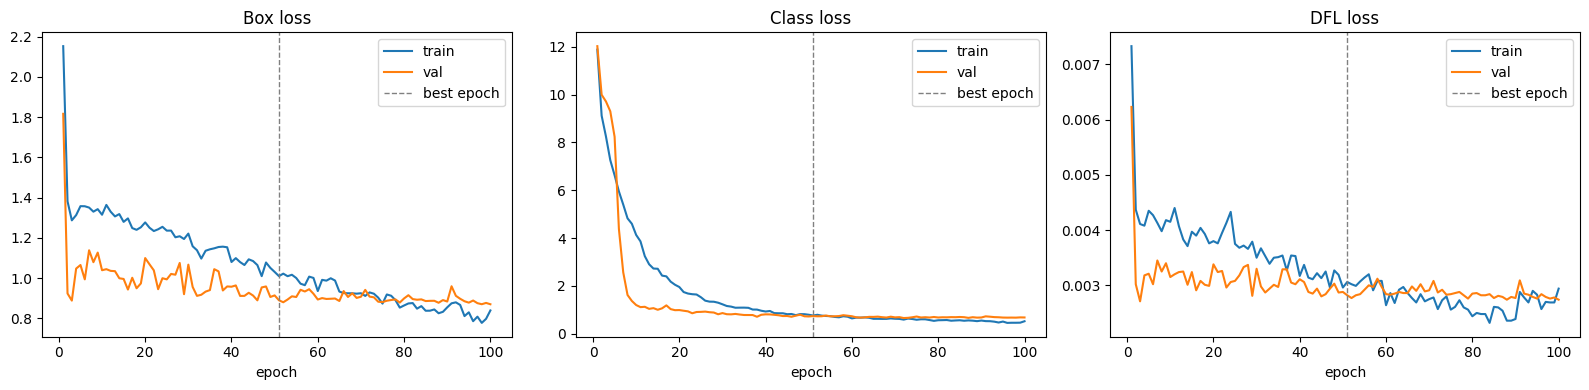

In [25]:
ep = df["epoch"]
best_ep = int(df["epoch"].iloc[best_i])

# --- losses: train vs val ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (key, title) in zip(axes, [("box_loss", "Box loss"),
                                    ("cls_loss", "Class loss"),
                                    ("dfl_loss", "DFL loss")]):
    ctr, cva = col(df, "train/" + key), col(df, "val/" + key)
    if ctr: ax.plot(ep, df[ctr], label="train")
    if cva: ax.plot(ep, df[cva], label="val")
    ax.axvline(best_ep, color="grey", ls="--", lw=1, label="best epoch")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.show()

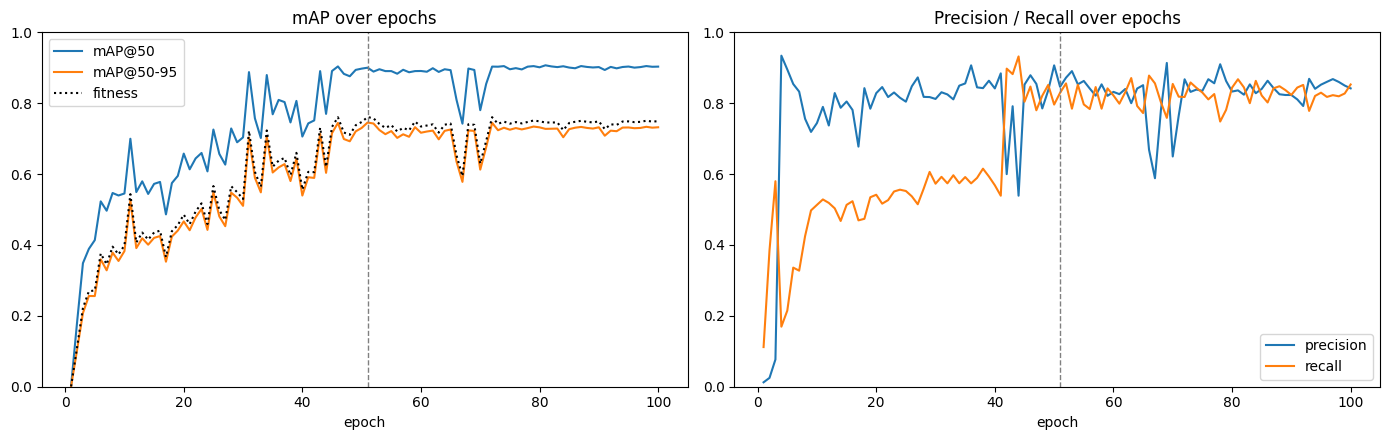

In [26]:
# --- metrics over epochs ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(ep, df[c_m50], label="mAP@50")
axes[0].plot(ep, df[c_m],   label="mAP@50-95")
axes[0].plot(ep, fitness,   label="fitness", ls=":", color="k")
axes[0].axvline(best_ep, color="grey", ls="--", lw=1)
axes[0].set_title("mAP over epochs"); axes[0].set_xlabel("epoch")
axes[0].set_ylim(0, 1); axes[0].legend()

axes[1].plot(ep, df[c_p], label="precision")
axes[1].plot(ep, df[c_r], label="recall")
axes[1].axvline(best_ep, color="grey", ls="--", lw=1)
axes[1].set_title("Precision / Recall over epochs"); axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1); axes[1].legend()
plt.tight_layout(); plt.show()

## 3. Convergence & overfitting diagnostics

- **Plateau** — did the last stretch of epochs still improve? If not, you could train fewer.
- **Early best** — if the best epoch is early, the tail added little.
- **Overfitting** — did val loss climb back up after its minimum while train loss kept falling? That gap is the classic "more data / more augmentation / earlier stop" signal.

In [27]:
n = len(df)
final_ep = int(df["epoch"].iloc[-1])

# plateau: fitness change over the last 20% of epochs
tail = max(1, n // 5)
recent_gain = float(fitness.iloc[-1] - fitness.iloc[-tail])
plateaued = abs(recent_gain) < 0.005

# overfitting: val loss min vs final
cva = col(df, "val/box_loss")
vmin_i = int(df[cva].idxmin())
vmin_ep = int(df["epoch"].iloc[vmin_i])
val_rise = float(df[cva].iloc[-1] - df[cva].min())

print("=== DIAGNOSTICS ===")
print(f"best epoch (max fitness): {best_ep} / {final_ep}  ({best_ep/final_ep:.0%} of the way in)")
print(f"mAP50-95:  best={df[c_m].iloc[best_i]:.3f}   final={df[c_m].iloc[-1]:.3f}")
print()
print(f"fitness change over last {tail} epochs: {recent_gain:+.4f}  -> "
      + ("PLATEAUED (could train fewer epochs / add patience)" if plateaued else "still improving"))
print()
print(f"val/box_loss: min={df[cva].min():.3f} @ epoch {vmin_ep}   final={df[cva].iloc[-1]:.3f}")
if vmin_ep < final_ep * 0.8 and val_rise > 0.02:
    print("  -> val loss rose after its minimum = OVERFITTING signal")
    print("     (more data / stronger augmentation / earlier stopping may help)")
else:
    print("  -> val loss did not meaningfully rise = not strongly overfitting")
if best_ep < final_ep * 0.6:
    print("  -> best epoch is early; later epochs added little value.")

=== DIAGNOSTICS ===
best epoch (max fitness): 51 / 100  (51% of the way in)
mAP50-95:  best=0.745   final=0.732

fitness change over last 20 epochs: +0.0037  -> PLATEAUED (could train fewer epochs / add patience)

val/box_loss: min=0.870 @ epoch 100   final=0.870
  -> val loss did not meaningfully rise = not strongly overfitting
  -> best epoch is early; later epochs added little value.


## 4. Ultralytics-generated plots

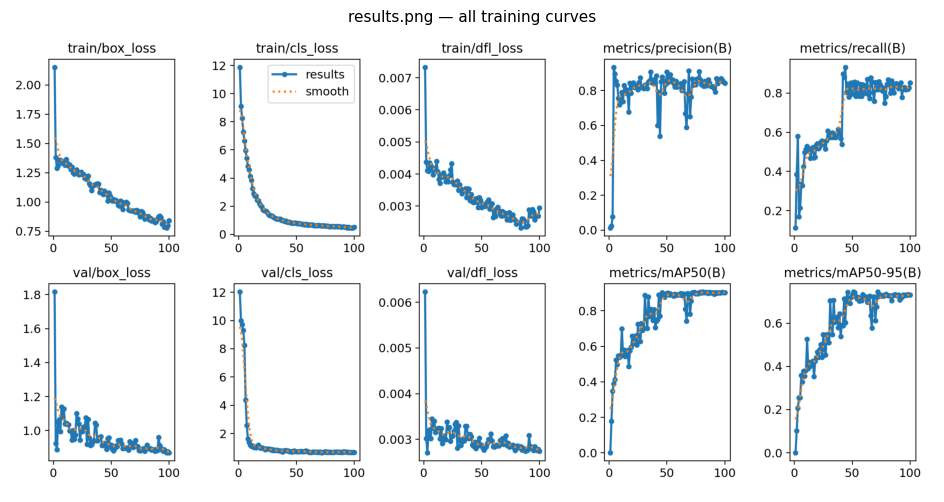

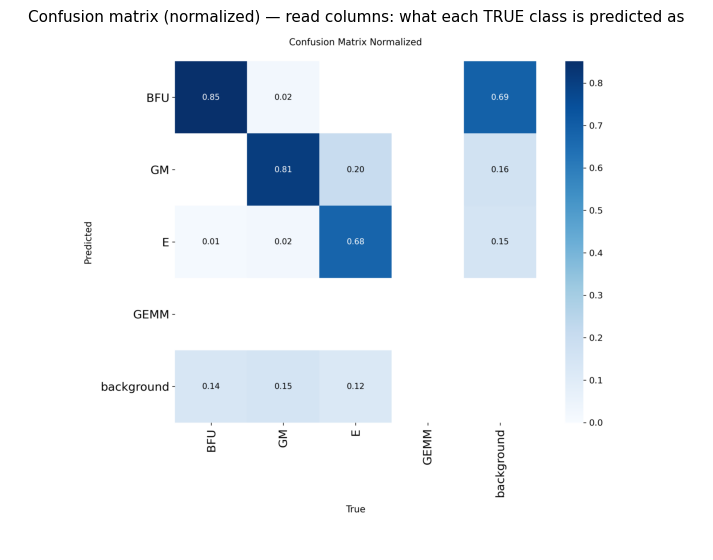

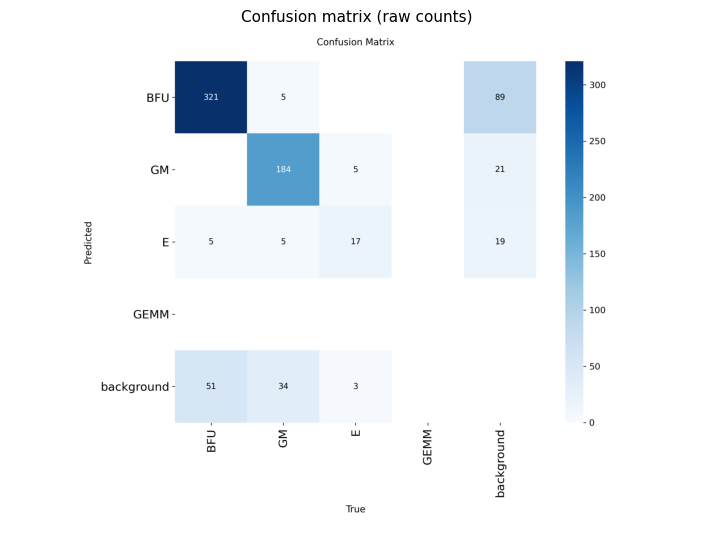

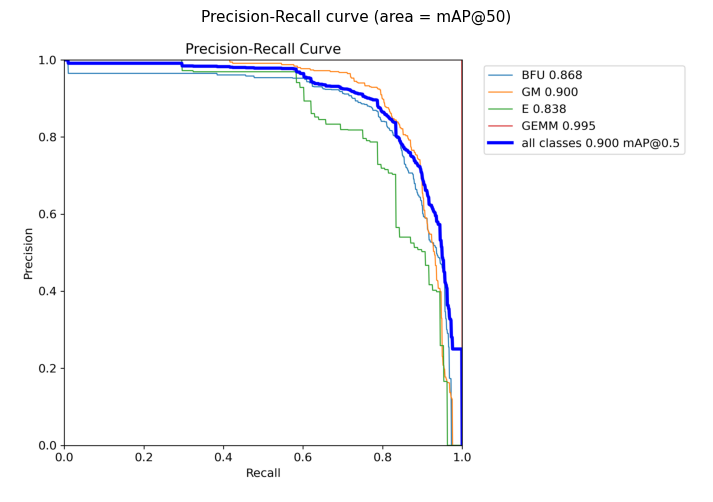

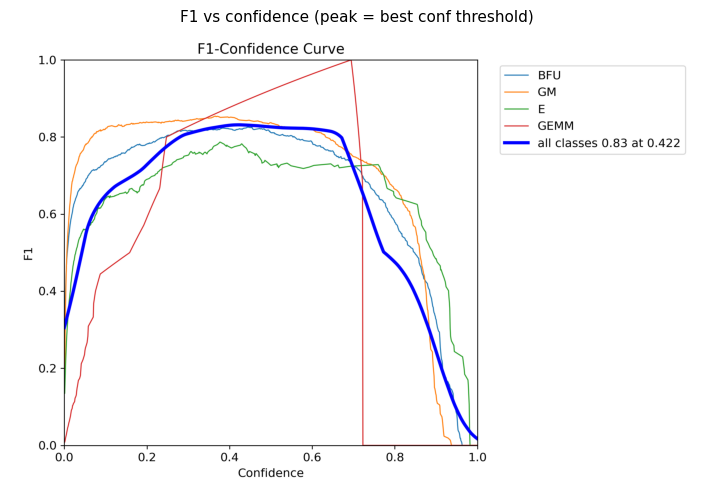

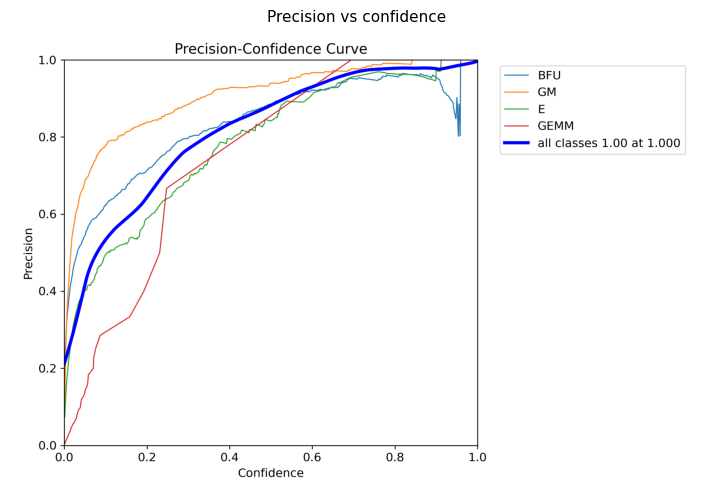

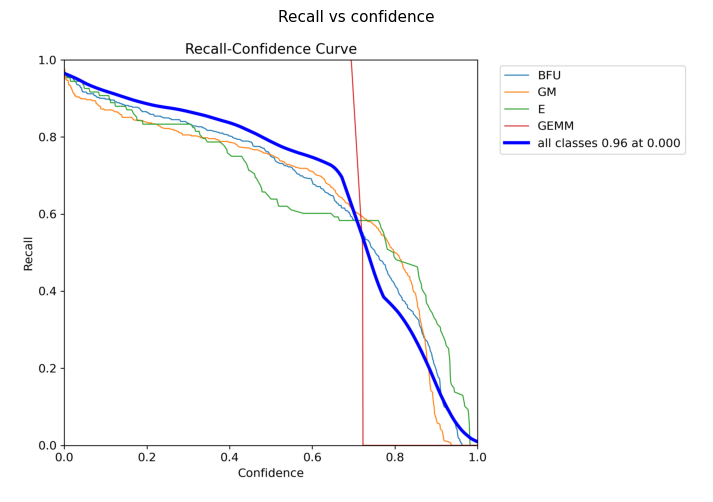

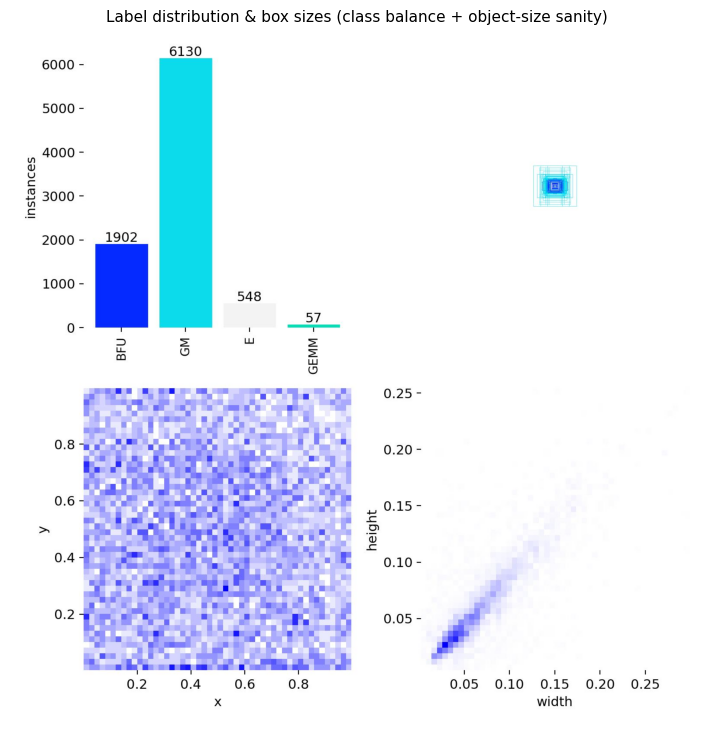

In [28]:
show_img(RUN_DIR / "results.png", "results.png — all training curves", width=12)
show_img(RUN_DIR / "confusion_matrix_normalized.png", "Confusion matrix (normalized) — read columns: what each TRUE class is predicted as")
show_img(RUN_DIR / "confusion_matrix.png", "Confusion matrix (raw counts)")
for f, t in [("BoxPR_curve.png", "Precision-Recall curve (area = mAP@50)"),
             ("BoxF1_curve.png", "F1 vs confidence (peak = best conf threshold)"),
             ("BoxP_curve.png",  "Precision vs confidence"),
             ("BoxR_curve.png",  "Recall vs confidence")]:
    show_img(RUN_DIR / f, t)
show_img(RUN_DIR / "labels.jpg", "Label distribution & box sizes (class balance + object-size sanity)")

## 5. Sample predictions — validation ground truth vs. model

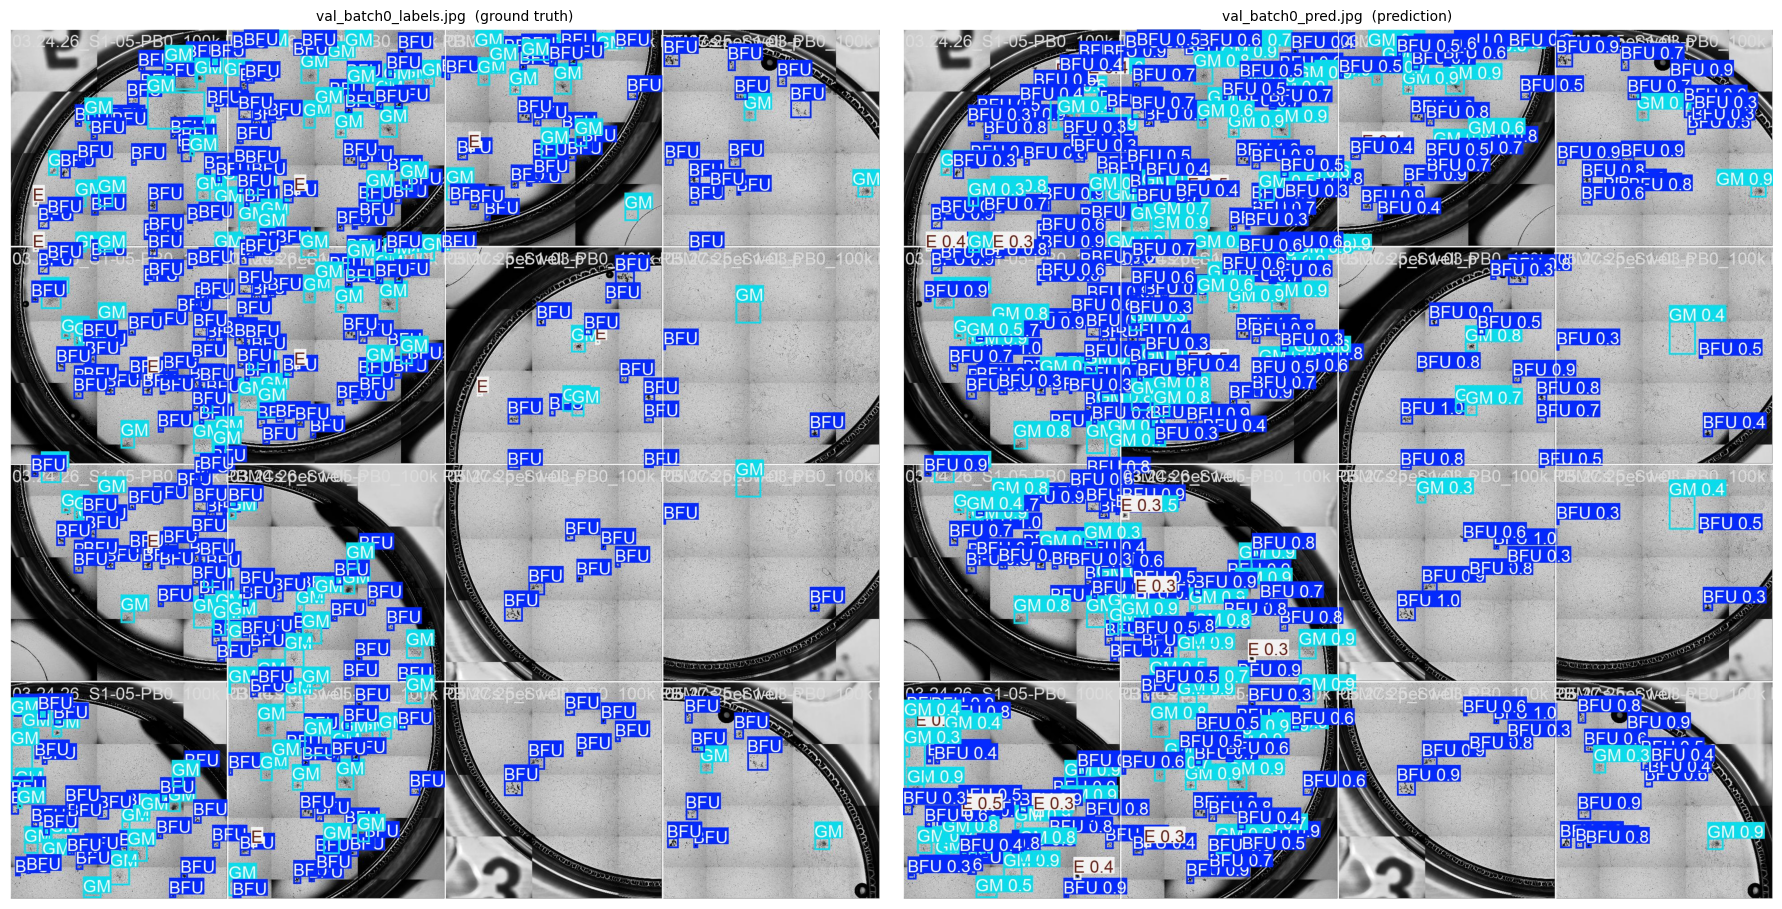

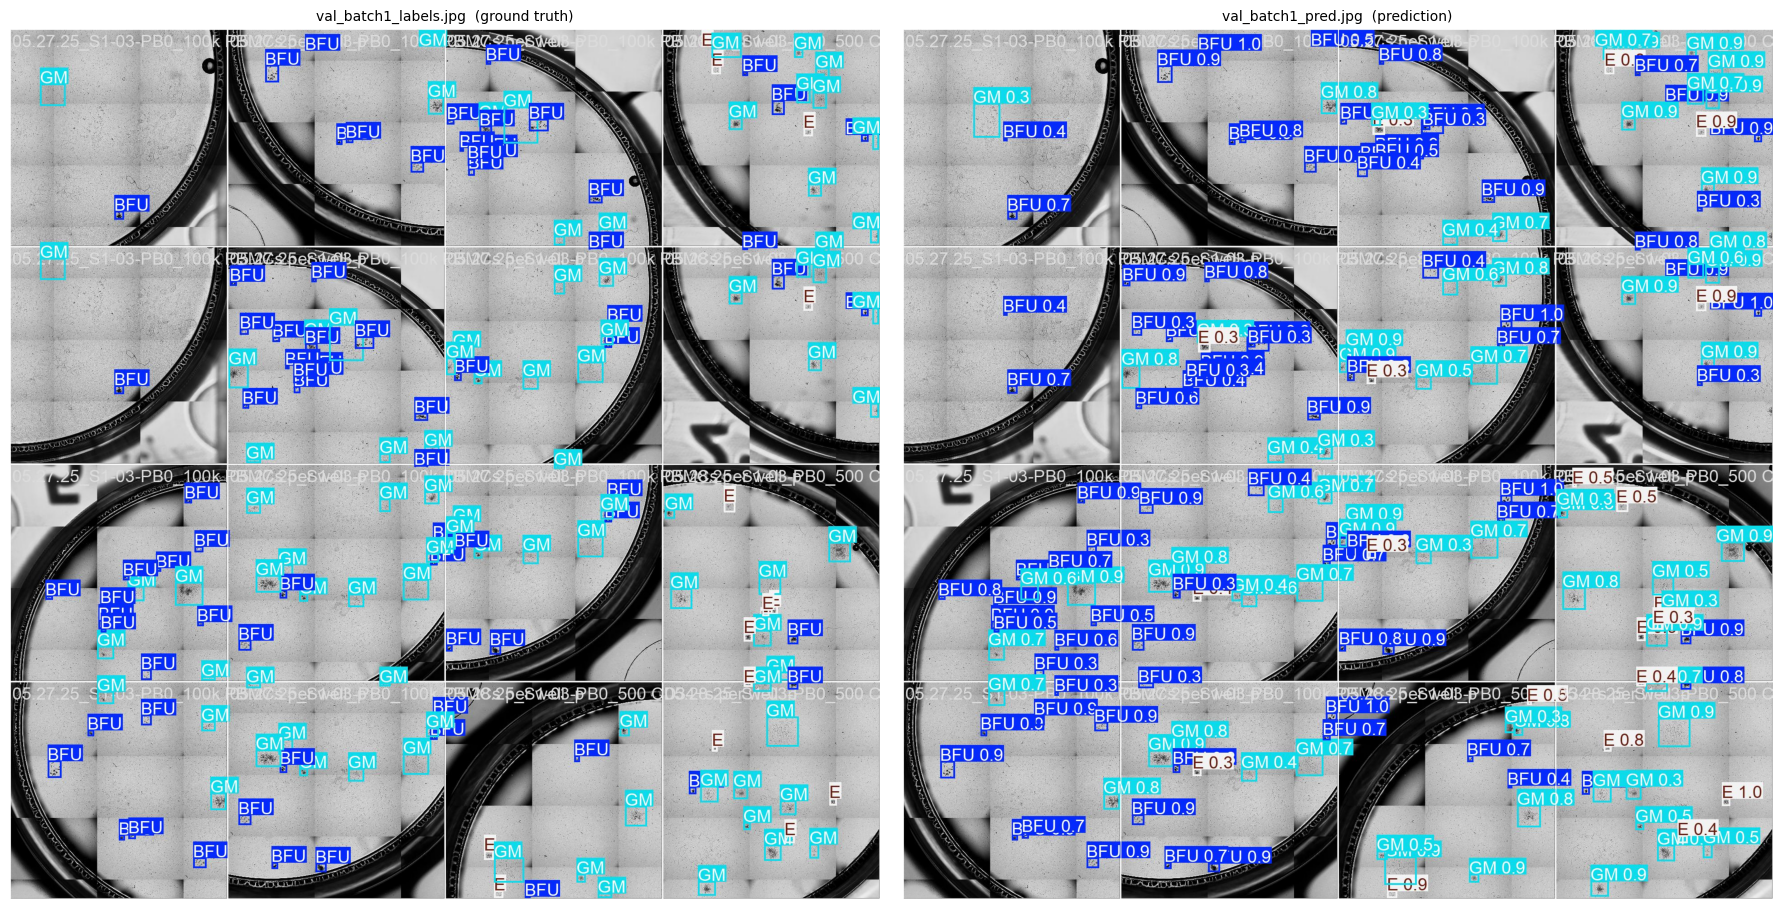

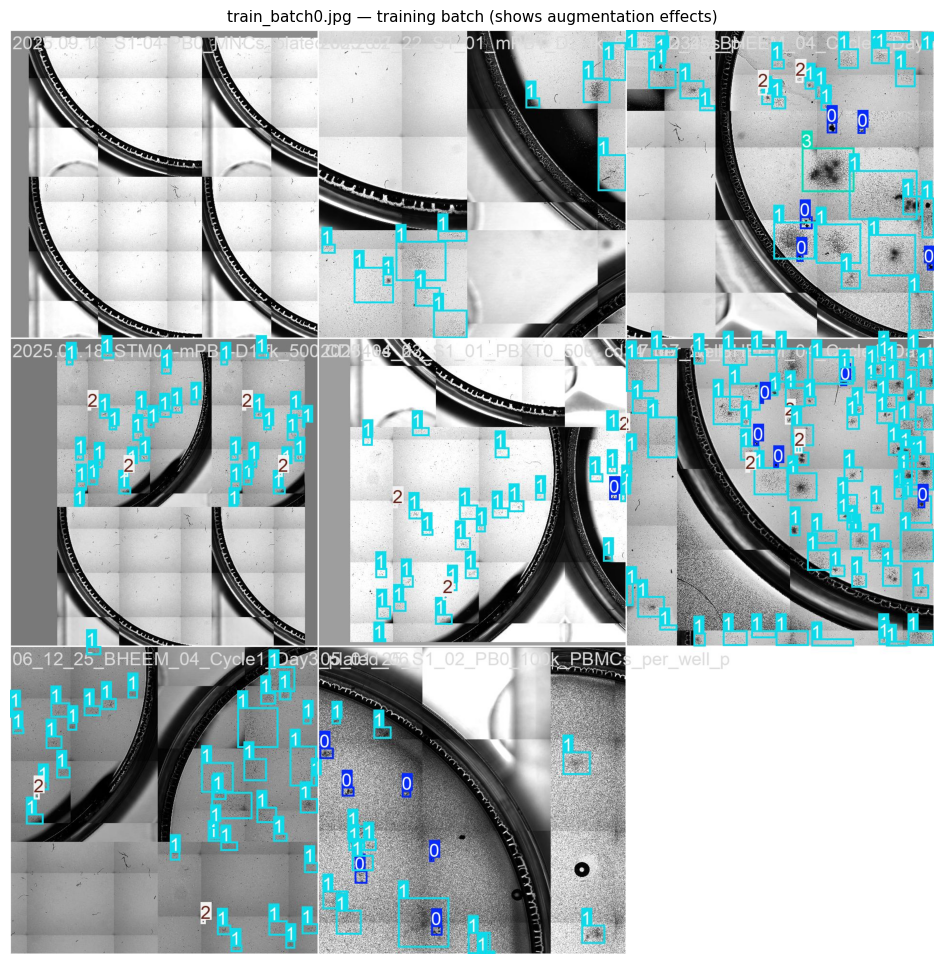

In [29]:
pairs = sorted(RUN_DIR.glob("val_batch*_labels.jpg"))
if not pairs:
    print("(no val_batch images in this run)")
for lab in pairs:
    pred = lab.with_name(lab.name.replace("_labels", "_pred"))
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    for ax, p, t in [(axes[0], lab, "ground truth"), (axes[1], pred, "prediction")]:
        if p.exists():
            ax.imshow(mpimg.imread(p))
        ax.set_title(f"{p.name}  ({t})", fontsize=10); ax.axis("off")
    plt.tight_layout(); plt.show()

# one training batch, to see augmentation in action
tb = sorted(RUN_DIR.glob("train_batch*.jpg"))
if tb:
    show_img(tb[0], f"{tb[0].name} — training batch (shows augmentation effects)", width=12)

## 6. Per-class metrics *(optional — re-runs validation)*

Set `RUN_VALIDATION = True` and `DATA_YAML` (with **local** paths) in the config
cell, then run this. It reloads `best.pt` and re-validates to produce a fresh
per-class table + bar chart.

**Bias vs. variance tip:** run it once with `VAL_SPLIT = "val"` and once with
`VAL_SPLIT = "train"`. A big train-over-val gap → variance → more data likely
helps. Similar and both mediocre → bias → look at labels / scale / model, not
volume.

In [30]:
if not RUN_VALIDATION:
    print("RUN_VALIDATION is False - skipping.")
    print("To get a fresh per-class table: set RUN_VALIDATION=True and DATA_YAML")
    print("(a data.yaml whose paths exist ON THIS MACHINE) in the config cell.")
    print("Tip: switch VAL_SPLIT between 'train' and 'val' for the bias/variance check.")
else:
    from ultralytics import YOLO

    # --- 0) sanity-check inputs BEFORE the slow val() call (clear errors, not cryptic ones) ---
    assert DATA_YAML, "Set DATA_YAML in the config cell (a data.yaml with LOCAL paths)."
    dy = Path(DATA_YAML)
    assert dy.exists(), f"DATA_YAML file not found: {dy}"
    dcfg = yaml.safe_load(dy.read_text())
    root = Path(dcfg.get("path", dy.parent))
    split_entry = dcfg.get(VAL_SPLIT)
    assert split_entry, f"data.yaml has no '{VAL_SPLIT}:' entry (has: {list(dcfg)})."
    split_dir = root / split_entry
    if not split_dir.exists():
        raise FileNotFoundError(
            f"'{VAL_SPLIT}' images not found on this machine:\n  {split_dir}\n"
            "Your repo data.yaml points at the CLUSTER path. Make a LOCAL copy of "
            "data.yaml whose `path:` is the dataset on this Mac, and set DATA_YAML to it."
        )
    best_pt = RUN_DIR / "weights" / "best.pt"
    assert best_pt.exists(), f"weights/best.pt missing in {RUN_DIR}"

    # --- 1) validate at the TRAINING imgsz -- a different imgsz makes the numbers meaningless ---
    val_imgsz = int(args.get("imgsz", 640))
    print(f"Validating {best_pt.name}  split='{VAL_SPLIT}'  imgsz={val_imgsz}")
    print("(imgsz must match training; on CPU at large imgsz this can take a while.)\n")
    model = YOLO(str(best_pt))
    res = model.val(data=str(dy), split=VAL_SPLIT, imgsz=val_imgsz, plots=False, verbose=True)

    # --- 2) per-class instance counts from the split's labels (for the data-limited read) ---
    lbl_dir = split_dir.parent / "labels"
    inst = {}
    if lbl_dir.exists():
        for txt in lbl_dir.glob("*.txt"):
            if txt.name in {"classes.txt", "obj.names"}:
                continue
            for line in txt.read_text().splitlines():
                if line.strip():
                    cid = int(line.split()[0]); inst[cid] = inst.get(cid, 0) + 1

    # --- 3) per-class table + chart ---
    try:
        names = res.names if isinstance(res.names, dict) else dict(enumerate(res.names))
        b = res.box
        idx = [int(i) for i in b.ap_class_index]
        table = pd.DataFrame({
            "class":     [names[i] for i in idx],
            "instances": [inst.get(i, 0) for i in idx],
            "precision": np.round(np.atleast_1d(b.p), 3),
            "recall":    np.round(np.atleast_1d(b.r), 3),
            "mAP50":     np.round(np.atleast_1d(b.ap50), 3),
            "mAP50-95":  np.round(np.atleast_1d(b.ap), 3),
        })
        display(table)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(table["class"], table["mAP50-95"])
        ax.set_ylim(0, 1); ax.set_ylabel("mAP@50-95")
        ax.set_title(f"Per-class mAP@50-95  (split={VAL_SPLIT}, imgsz={val_imgsz})")
        for i, v in enumerate(table["mAP50-95"]):
            ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
        plt.show()
        print("\nClasses low on BOTH instances and mAP are data-limited; a class with many "
              "instances but low mAP is limited by something else (labels / density / scale).")
    except Exception as e:
        print("Could not build the per-class table automatically:", repr(e))
        print("The per-class numbers are printed in the validation output above.")

FileNotFoundError: 'val' images not found on this machine:
  /home/mzhai72/CFU_classifier/data/split_AI/val/images
Your repo data.yaml points at the CLUSTER path. Make a LOCAL copy of data.yaml whose `path:` is the dataset on this Mac, and set DATA_YAML to it.